In [43]:
import pandas as pd
import os
from pathlib import Path
from sklearn.linear_model import LinearRegression
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings

In [44]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'
df = pd.read_csv(path_data/"data.csv")
df = df.drop(columns=['Unnamed: 0']).query('2021<year | year<=2020').copy()
df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NAC'], errors='coerce')
regiones = df.region.unique()
df = df.assign(nac_nov=lambda x: np.where((x.FECHA_NAC.dt.year == 2019) & (x.FECHA_NAC.dt.month == 11), 1, 0),
               nac_sep=lambda x: np.where((x.FECHA_NAC.dt.year == 2018) & (x.FECHA_NAC.dt.month == 9), 1, 0)).copy()

In [ ]:
hospitalizations_total = (df
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('nac_nov == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)

for i in regiones:
    
    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    
    hospitalizations_nov_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_nov_reg, on=['year', 'epiweek'], how='left')

    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    hospitalizations = hospitalizations.assign(
        year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
        epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
        ).copy()
    
    
    
    hospitalizations_2019 = hospitalizations[hospitalizations['year'] == 2019]

    hospitalizations_2024 = hospitalizations[hospitalizations['year'] == 2024]

    epiweeks_2024 = hospitalizations_2024['epiweek'].unique() 
    
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek'])]

    X_train = hospitalizations_2019_train['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['regional_hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    
    
    weeks_2024 = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))')['epiweek_ext'].unique() 

    # Usar las hospitalizaciones de 2022 desplazadas como entrada para predecir todo 2024
    X_full = hospitalizations.query('year_ext==2019')['regional_hospitalizations'].values.reshape(-1, 1)

    # Predecir usando el modelo ya entrenado
    predicted_2024_full = model.predict(X_full)
    
    predictions_df = pd.DataFrame({
        'epiweek_ext': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })

    hospitalizations_merged = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))').merge(predictions_df, on='epiweek_ext', how='left')


    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']

    hospitalizations_merged = hospitalizations_merged[['year_ext', 'epiweek_ext', 'regional_hospitalizations', 'predicted_2024', 'percentage_nov', 'predicted_nov_2024']]

    plt.figure(figsize=(10,6))

    # Graficar el histograma de nacidos en noviembre 2024 usando barras
    plt.bar(hospitalizations_merged['epiweek_ext'], hospitalizations_merged['predicted_nov_2024'].cumsum(), color='green', edgecolor='black', label='Curva nacidos nov 2024')

    # Añadir etiquetas y título
    plt.xlabel('Semana del año')
    plt.ylabel('Número de hospitalizaciones')
    plt.title(f'VRS de nacidos en noviembre 2024: region {i}')

    # Mostrar todos los valores enteros en el eje X
    plt.xticks(np.arange(hospitalizations_merged['epiweek_ext'].min(), hospitalizations_merged['epiweek_ext'].max()+1, 1))

    # Añadir leyenda
    plt.legend()

    # Mostrar el gráfico
    plt.show()


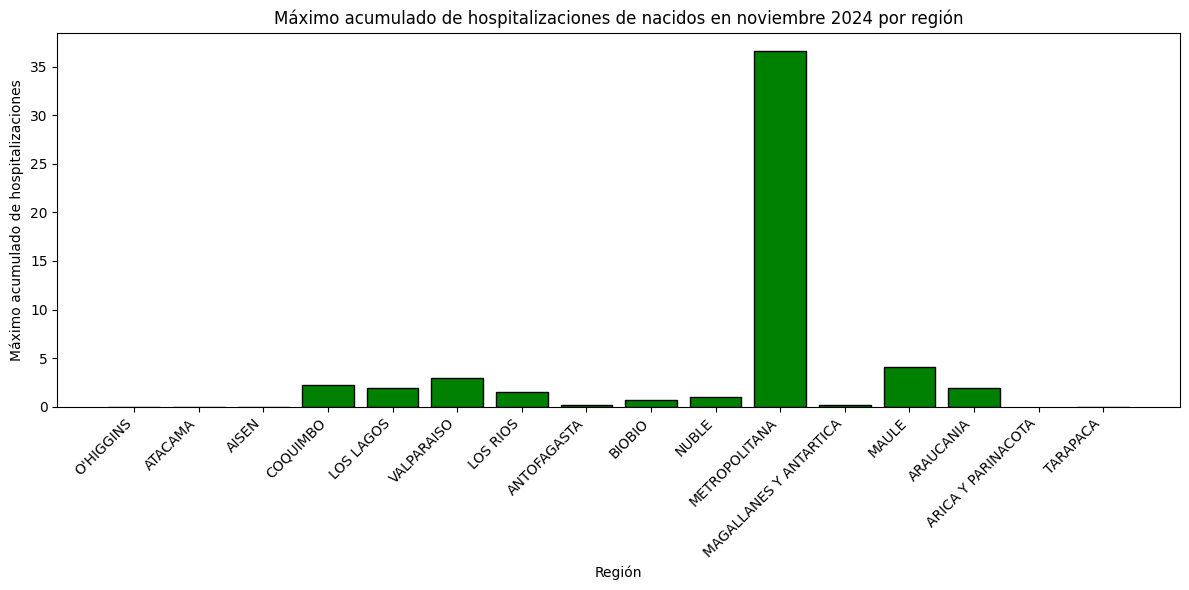

In [68]:
hospitalizations_total = (df
                          .query('elegibilidad!=year')
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('elegibilidad!=year & nac_nov == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)
# Crear un diccionario para almacenar los valores máximos de cumsum de cada región
max_cumsum_by_region_noviembre = {}

for i in regiones:   
    # Procesar los datos y realizar el ajuste del modelo como en tu código original
    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    hospitalizations_nov_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_nov_reg, on=['year', 'epiweek'], how='left')
    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)
    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    hospitalizations = hospitalizations.assign(
        year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
        epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    ).copy()
    
    # Selección y entrenamiento del modelo
    hospitalizations_2019 = hospitalizations[hospitalizations['year'] == 2019]
    hospitalizations_2024 = hospitalizations[hospitalizations['year'] == 2024]
    epiweeks_2024 = hospitalizations_2024['epiweek'].unique() 
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek'])]
    
    X_train = hospitalizations_2019_train['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['regional_hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predicción para 2024 completa
    weeks_2024 = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))')['epiweek_ext'].unique() 
    X_full = hospitalizations.query('year_ext==2019')['regional_hospitalizations'].values.reshape(-1, 1)
    predicted_2024_full = model.predict(X_full)
    
    # Crear DataFrame con las predicciones y calcular cumsum
    predictions_df = pd.DataFrame({
        'epiweek_ext': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })
    hospitalizations_merged = hospitalizations.query('((year_ext == 2020) & (epiweek_ext <= 13)) | ((year_ext==2019 & epiweek_ext>=45))').merge(predictions_df, on='epiweek_ext', how='left')
    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']
    
    # Calcular el valor máximo de la curva acumulada para la región actual y almacenarlo
    max_cumsum_by_region_noviembre[i] = hospitalizations_merged['predicted_nov_2024'].cumsum().max()

# Paso final: Crear el gráfico con los valores máximos de cumsum de cada región

plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(max_cumsum_by_region_noviembre.keys(), max_cumsum_by_region_noviembre.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones de nacidos en noviembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

In [ ]:
hospitalizations_total = (df
                          .query('elegibilidad!=year')
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('elegibilidad!=year')
                        .query('nac_sep == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)

for i in regiones:
    
    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    
    hospitalizations_nov_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_nov_reg, on=['year', 'epiweek'], how='left')

    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)

    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    hospitalizations = hospitalizations.assign(
        year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
        epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
        ).copy()
    
    weeks_2024 = hospitalizations.query('year==2019')['epiweek'].unique() 

    # Usar las hospitalizaciones de 2022 desplazadas como entrada para predecir todo 2024
    X_full = hospitalizations.query('year==2019')['regional_hospitalizations'].values.reshape(-1, 1)

    # Predecir usando el modelo ya entrenado
    predicted_2024_full = model.predict(X_full)
    
    predictions_df = pd.DataFrame({
        'epiweek': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })

    hospitalizations_merged = hospitalizations.query('year==2019').merge(predictions_df, on='epiweek', how='left')


    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']

    hospitalizations_merged = hospitalizations_merged[['year_ext', 'epiweek', 'regional_hospitalizations', 'predicted_2024', 'percentage_nov', 'predicted_nov_2024']]

    plt.figure(figsize=(10,6))

    # Graficar el histograma de nacidos en noviembre 2024 usando barras
    plt.bar(hospitalizations_merged['epiweek'], hospitalizations_merged['predicted_nov_2024'].cumsum(), color='green', edgecolor='black', label='Curva nacidos nov 2024')

    # Añadir etiquetas y título
    plt.xlabel('Semana del año')
    plt.ylabel('Número de hospitalizaciones')
    plt.title(f'VRS de nacidos en septiembre 2024: region {i}')

    # Mostrar todos los valores enteros en el eje X
    plt.xticks(np.arange(hospitalizations_merged['epiweek'].min(), hospitalizations_merged['epiweek'].max()+1, 1))

    # Añadir leyenda
    plt.legend()

    # Mostrar el gráfico
    plt.show()


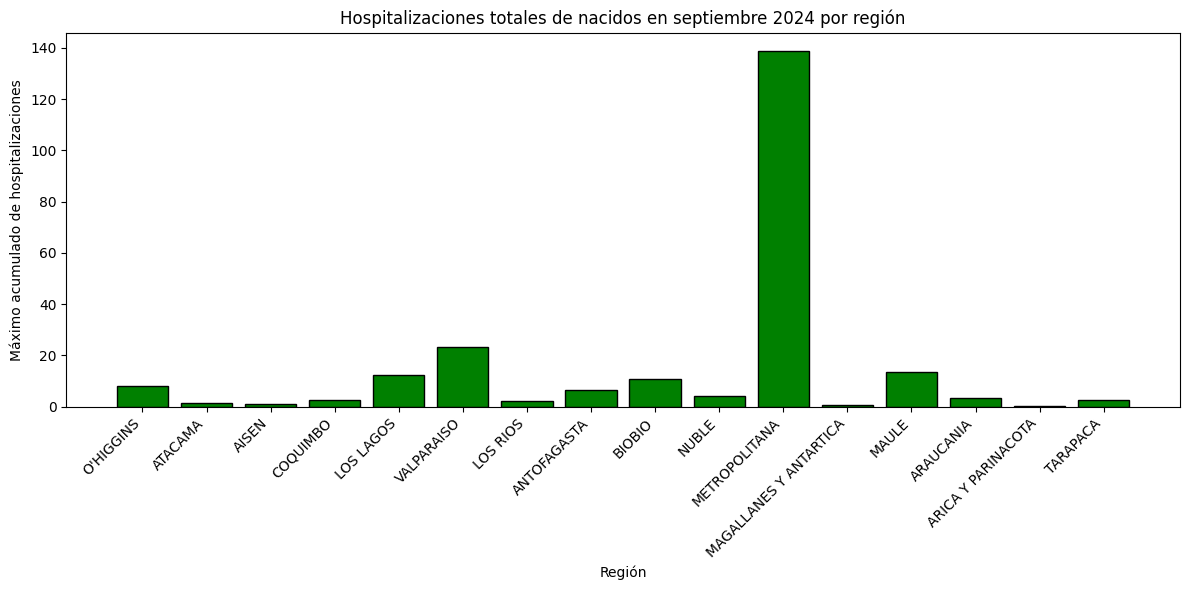

In [69]:
hospitalizations_total = (df
                          .query('elegibilidad!=year')
                          .groupby(['year', 'epiweek', 'region'])
                          .size().reset_index(name='hospitalizations')
                          .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                          .reset_index()
                          .copy()
)

hospitalizations_nov = (df
                        .query('elegibilidad!=year')
                        .query('nac_sep == 1')
                        .groupby(['year', 'epiweek', 'region'])
                        .size()
                        .reset_index(name='hospitalizations')
                        .pivot(index=['year', 'epiweek'], columns='region', values='hospitalizations').fillna(0)
                        .reindex(columns=regiones, fill_value=0)  
                        .reset_index()
                        .copy()
)


max_cumsum_by_region_septiembre = {}

for i in regiones:   
    # Procesar los datos y realizar el ajuste del modelo como en tu código original
    hospitalizations_reg = hospitalizations_total[['year', 'epiweek', i]].copy().rename(columns = {i:'regional_hospitalizations'})
    hospitalizations_nov_reg = hospitalizations_nov[['year', 'epiweek',i]].copy().rename(columns = {i:'nov_hospitalizations'})
    
    hospitalizations = pd.merge(hospitalizations_reg, hospitalizations_nov_reg, on=['year', 'epiweek'], how='left')
    hospitalizations['nov_hospitalizations'] = hospitalizations['nov_hospitalizations'].fillna(0)
    hospitalizations['percentage_nov'] = (hospitalizations['nov_hospitalizations'] / hospitalizations['regional_hospitalizations']) * 100

    hospitalizations = hospitalizations.assign(
        year_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), 2019, x.year),
        epiweek_ext = lambda x: np.where((x.year == 2020) & (x.epiweek <= 13), x.epiweek + 52, x.epiweek)
    ).copy()
    
    # Selección y entrenamiento del modelo
    hospitalizations_2019 = hospitalizations[hospitalizations['year'] == 2019]
    hospitalizations_2024 = hospitalizations[hospitalizations['year'] == 2024]
    epiweeks_2024 = hospitalizations_2024['epiweek'].unique() 
    hospitalizations_2019_train = hospitalizations_2019[hospitalizations_2019['epiweek'].isin(epiweeks_2024)]  
    hospitalizations_2024_train = hospitalizations_2024[hospitalizations_2024['epiweek'].isin(hospitalizations_2019_train['epiweek'])]
    
    X_train = hospitalizations_2019_train['regional_hospitalizations'].values.reshape(-1, 1)
    y_train = hospitalizations_2024_train['regional_hospitalizations'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    
    weeks_2024 = hospitalizations.query('year==2019')['epiweek'].unique() 
    X_full = hospitalizations.query('year==2019')['regional_hospitalizations'].values.reshape(-1, 1)
    predicted_2024_full = model.predict(X_full)
    
    # Crear DataFrame con las predicciones y calcular cumsum
    predictions_df = pd.DataFrame({
        'epiweek': weeks_2024,
        'predicted_2024': predicted_2024_full[:len(weeks_2024)] 
    })
    hospitalizations_merged = hospitalizations.query('year==2019').merge(predictions_df, on='epiweek', how='left')
    hospitalizations_merged['predicted_nov_2024'] = (hospitalizations_merged['percentage_nov'] / 100) * hospitalizations_merged['predicted_2024']
    
    # Calcular el valor máximo de la curva acumulada para la región actual y almacenarlo
    max_cumsum_by_region_septiembre[i] = hospitalizations_merged['predicted_nov_2024'].cumsum().max()

# Paso final: Crear el gráfico con los valores máximos de cumsum de cada región

plt.figure(figsize=(12, 6))

# Graficar las regiones en el eje x y sus valores máximos de cumsum en el eje y
plt.bar(max_cumsum_by_region_septiembre.keys(), max_cumsum_by_region_septiembre.values(), color='green', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Hospitalizaciones totales de nacidos en septiembre 2024 por región')

# Rotar las etiquetas del eje X para evitar solapamientos
plt.xticks(rotation=45, ha='right')  # Rotación de 90 grados y alineación a la derecha

# Mostrar el gráfico
plt.tight_layout()  # Ajustar el layout para que no se corten las etiquetas
plt.show()

In [ ]:
max_cumsum_by_region_septiembre 

with open('dict_resul_week.pkl', 'rb') as pickle_file:
    max_cumsum_by_region_septiembre = pickle.load(pickle_file)

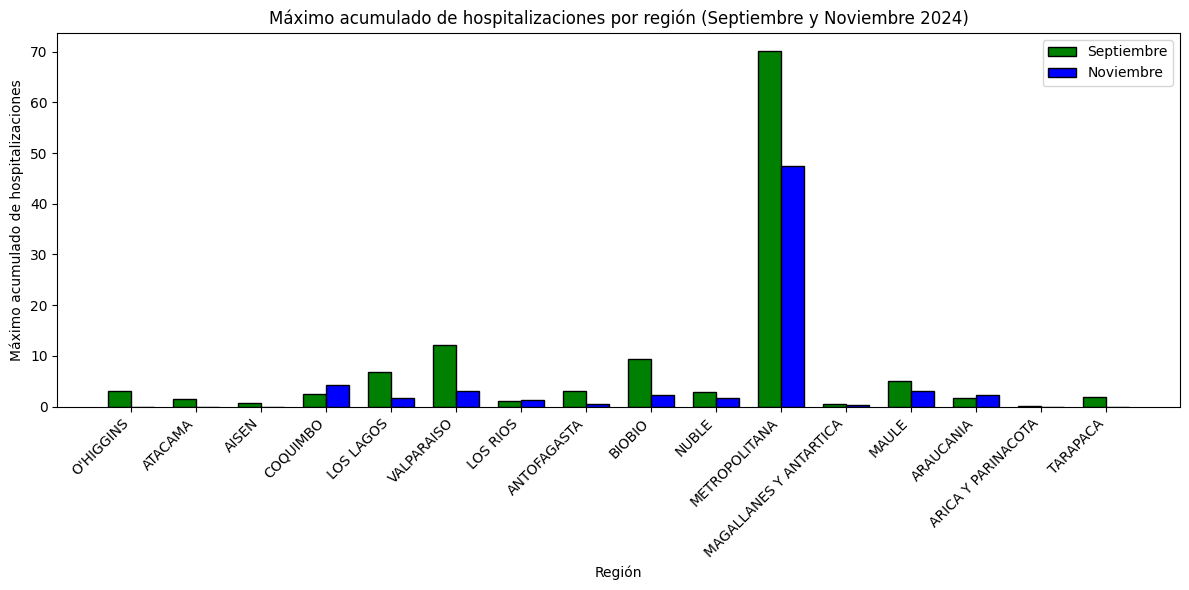

In [55]:
# Unir los datos de ambos gráficos
regiones = list(max_cumsum_by_region_septiembre.keys())
septiembre_values = list(max_cumsum_by_region_septiembre.values())
noviembre_values = list(max_cumsum_by_region_noviembre.values())

# Índice para las regiones en el eje X
x = np.arange(len(regiones))

# Ancho de las barras
bar_width = 0.35

# Crear el gráfico con barras agrupadas
plt.figure(figsize=(12, 6))

# Graficar las barras para septiembre
plt.bar(x - bar_width/2, septiembre_values, bar_width, label='Septiembre', color='green', edgecolor='black')

# Graficar las barras para noviembre
plt.bar(x + bar_width/2, noviembre_values, bar_width, label='Noviembre', color='blue', edgecolor='black')

# Añadir etiquetas y título
plt.xlabel('Región')
plt.ylabel('Máximo acumulado de hospitalizaciones')
plt.title('Máximo acumulado de hospitalizaciones por región (Septiembre y Noviembre 2024)')

# Añadir las etiquetas de las regiones en el eje X
plt.xticks(x, regiones, rotation=45, ha='right')

# Añadir leyenda
plt.legend()

# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar el gráfico
plt.show()
